# The Powerplay Effect: Predicting Early-Over Impact and Prescribing Winning Strategies in IPL Cricket

## **Abstract**
The Powerplay (first 6 overs) in T20 cricket is often the most decisive phase of the match. This project investigates how Powerplay performance influences match outcomes in the Indian Premier League (IPL). Using comprehensive IPL match data and Powerplay statistics, we build machine learning models to predict match outcomes based on early-over performance and contextual match features. In addition to predictive modeling, we develop prescriptive analytics to recommend actionable strategies such as optimal run targets, wicket-preserving behavior, and venue-specific Powerplay plans. The goal is to help teams, analysts, and coaches understand how to maximize Powerplay advantage and improve win probabilities.

## **Business Use Case**

The Powerplay determines momentum, batting strategy, successful chasing probability, and overall match direction in the IPL. Teams frequently struggle with:
- Whether to attack early or preserve wickets  
- How many runs they need in the PP to stay competitive  
- How venue and pitch factors alter PP approach  
- How toss decision influences early-over game plans  

### **Why This Model Matters**
- Coaches can adjust aggression levels in Powerplay based on predicted outcomes.
- Analysts can forecast match probability after PP ends.
- Broadcasters can display real-time win probability graphics.
- Teams can adjust batting rankings and PP strike rates.  
- Strategic decisions such as "attack mode", "anchor mode", or "hybrid PP strategy" become data-driven.

This project delivers both predictive and prescriptive intelligence, enabling teams to anticipate match outcomes and act proactively during Powerplay.

## **Dataset Description**

### **Source**
Kaggle Dataset: IPL Men’s Cricket Matches (2008–2023)

### **Dataset Includes**
- Match-level data for 1000+ IPL games  
- Ball-by-ball data aggregated into Powerplay statistics  
- Teams, venues, toss results, innings  
- Derived performance metrics  

### **Size**
- ~18,000 ball-by-ball rows (raw)  
- ~1200 processed match-level rows   

This dataset is suitable for machine learning classification tasks and prescriptive analytics.

## Data Loading and Initial Exploration

We begin by loading the processed IPL match-level dataset containing Powerplay statistics and key match context features.  
The goal of this step is to quickly check that the data has been imported correctly, understand its structure, and identify any missing values or inconsistencies that need attention before analysis and modelling.

In [54]:
# Install Necessary IMPORTS

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from IPython.display import FileLink
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
# LOAD Matches and Deliveries FILES

matches = pd.read_csv('/Users/avinashrajasekar/Downloads/IPL Project/Stats Project 2/matches.csv')
deliveries = pd.read_csv('/Users/avinashrajasekar/Downloads/IPL Project/Stats Project 2/deliveries.csv')

In [56]:
# Data Cleaning - matches.csv

# Display first few rows to understand structure
matches.head()
# Number of rows and columns before filtering
matches.shape
# Shows column types, memory usage, and missing entries
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [57]:
# Removing extra features from the match dataset , keeping necessary feature for efficient processing

cols_to_drop_matches = [
    "umpire1", "umpire2", "player_of_match",
    "match_type", "super_over","method"
]

matches_clean = matches.drop(columns=cols_to_drop_matches)

In [58]:
# Display first few rows of necessary columns
matches_clean.head()

,id,season,city,date,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs
0,335982,2007/08,Bangalore,2008-04-18,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0
1,335983,2007/08,Chandigarh,2008-04-19,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0
2,335984,2007/08,Delhi,2008-04-19,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0
3,335985,2007/08,Mumbai,2008-04-20,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0
4,335986,2007/08,Kolkata,2008-04-20,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0


In [59]:
# Number of rows and columns after filtering
matches_clean.shape
# Count missing values in each column
matches_clean.isnull().sum()

id                0
season            0
city             51
date              0
venue             0
team1             0
team2             0
toss_winner       0
toss_decision     0
winner            5
result            0
result_margin    19
target_runs       3
target_overs      3
dtype: int64

In [60]:

# First, remove columns that are unnecessary for analysis or modeling.
matches_clean = matches.drop(columns=cols_to_drop_matches)  

# Replace missing values in the 'city' column with 'Unknown' so that locationless matches remain without introducing errors.
matches_clean['city'] = matches_clean['city'].fillna('Unknown')  

# Drop any row where 'winner' is missing. These matches were likely abandoned or incomplete, which means they shouldn't be used for ML.
matches_clean = matches_clean.dropna(subset=['winner']).copy()  
 
# Fill missing 'result_margin' with 0 since matches that end in a tie, super-over, or don't have a margin should have a neutral value.
matches_clean['result_margin'] = matches_clean['result_margin'].fillna(0) 
 
# Eliminate matches with missing 'target_runs' or 'target_overs' because they indicate incomplete or invalid contests not useful for analysis.
matches_clean = matches_clean.dropna(subset=['target_runs', 'target_overs']) 


In [61]:
# Count missing values in each column
matches_clean.isnull().sum()

id               0
season           0
city             0
date             0
venue            0
team1            0
team2            0
toss_winner      0
toss_decision    0
winner           0
result           0
result_margin    0
target_runs      0
target_overs     0
dtype: int64

In [62]:
# Data Cleaning - deliveries.csv

# Display the first few rows to understand the structure
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [63]:
# Number of rows and columns before filtering
deliveries.shape
# Shows column types,missing entries
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [64]:
# Removing extra features from the deliveries dataset,  keeping necessary feature for efficient processing

deliveries_clean = deliveries[[
    "match_id", "inning", "batting_team", "bowling_team",
    "over", "ball", "total_runs", "is_wicket"
]]

In [65]:
# Display first few rows of necessary columns
deliveries_clean.head()

,match_id,inning,batting_team,bowling_team,over,ball,total_runs,is_wicket
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,1,0
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,0,0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,1,0
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,0,0
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,0,0


In [66]:
# Count missing values in each column
deliveries_clean.isnull().sum()
# Number of rows and columns after filtering
deliveries_clean.shape

(260920, 8)

In [67]:
# MERGE MATCHES + DELIVERIES

final_merged = deliveries_clean.merge(
    matches_clean,
    left_on="match_id",
    right_on="id",
    how="inner"
)

In [68]:
# Display the first few rows
final_merged .head()

,match_id,inning,batting_team,bowling_team,over,ball,total_runs,is_wicket,id,season,...,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,1,0,335982,2007/08,...,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,0,0,335982,2007/08,...,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,1,0,335982,2007/08,...,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,0,0,335982,2007/08,...,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,0,0,335982,2007/08,...,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0


In [69]:
# Number of rows and columns after merging
final_merged.shape

(260430, 22)

In [70]:
# List all columns
final_merged.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'total_runs', 'is_wicket', 'id', 'season', 'city', 'date', 'venue',
       'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result',
       'result_margin', 'target_runs', 'target_overs'],
      dtype='object')

In [71]:
# Data types by column
final_merged.dtypes

match_id           int64
inning             int64
batting_team      object
bowling_team      object
over               int64
ball               int64
total_runs         int64
is_wicket          int64
id                 int64
season            object
city              object
date              object
venue             object
team1             object
team2             object
toss_winner       object
toss_decision     object
winner            object
result            object
result_margin    float64
target_runs      float64
target_overs     float64
dtype: object

In [72]:
# Count missing values per column
final_merged.isnull().sum()

match_id         0
inning           0
batting_team     0
bowling_team     0
over             0
ball             0
total_runs       0
is_wicket        0
id               0
season           0
city             0
date             0
venue            0
team1            0
team2            0
toss_winner      0
toss_decision    0
winner           0
result           0
result_margin    0
target_runs      0
target_overs     0
dtype: int64

In [73]:
# Save to CSV
final_merged.to_csv("Cleaned_dataset.csv", index=False)
FileLink('Cleaned_dataset.csv')

/Users/avinashrajasekar/Downloads/IPL Project/Stats Project 2/Cleaned_dataset.csv

In [74]:
# Powerplay extraction

Merged = pd.read_csv('/Users/avinashrajasekar/Downloads/IPL Project/Stats Project 2/Cleaned_dataset.csv', low_memory=False)

In [75]:
# Since we are going to predict using PowerPlay, i.e, overs ( 0 - 5 ), we are removing other overs from the Over Column
powerplay_df = Merged[Merged["over"].between(0, 5)]

In [76]:
pp_summary = powerplay_df.groupby("match_id").agg(
    pp_runs=("total_runs", "sum"),      # For each match, compute the total powerplay runs by summing 'total_runs'
    pp_wickets=("is_wicket", "sum")     # For each match, compute the total powerplay wickets by summing 'is_wicket'
).reset_index()                         # Reset index so 'match_id' becomes a normal column

# Additional PP strength features
pp_summary["pp_runrate"] = pp_summary["pp_runs"] / 6
pp_summary["pp_wicketrate"] = pp_summary["pp_wickets"] / 6

In [77]:
# Display the first few rows
pp_summary.head()

,match_id,pp_runs,pp_wickets,pp_runrate,pp_wicketrate
0,335982,87,5,14.500000,0.833333
1,335983,116,2,19.333333,0.333333
2,335984,95,3,15.833333,0.500000
3,335985,87,4,14.500000,0.666667
4,335986,65,5,10.833333,0.833333


In [78]:
# Count missing values per column
pp_summary.isnull().sum()

match_id         0
pp_runs          0
pp_wickets       0
pp_runrate       0
pp_wicketrate    0
dtype: int64

In [79]:
# Number of rows and columns 
pp_summary.shape

(1090, 5)

In [80]:
# Build match-level dataset

match_info = Merged.drop_duplicates(subset=["match_id"])[[
    "match_id",
    "team1", "team2",
    "batting_team", "bowling_team",
    "winner",
    "toss_winner", "toss_decision",
    "season", "venue", "city", "date",
    "result", "result_margin",
    "target_runs", "target_overs",
    "inning"
]]

In [81]:
# Who batted first?
# 1 if team bats in first innings, else 0
match_info["bat_first"] = (match_info["inning"] == 1).astype(int)

# Toss winner is the same as the batting team?
# 1 if the toss winner chose to bat first, 0 otherwise
match_info["toss_win_for_batting_team"] = (
    match_info["batting_team"] == match_info["toss_winner"]
).astype(int)

# Toss decision numeric (1 = bat first, 0 = field)
match_info["toss_decision_is_bat"] = (match_info["toss_decision"] == "bat").astype(int)

# Win label (1 = won, 0 = lost)
match_info["won"] = (match_info["batting_team"] == match_info["winner"]).astype(int)

In [82]:
# Merging Powerplay extraction and match-level dataset

ml_df = match_info.merge(
    pp_summary,         # Merge with data containing powerplay summary statistics
    on="match_id",      # Use 'match_id' column in both DataFrames as the join key
    how="left"          # Keep all rows from match_info, bring in matching rows from pp_summary
)

In [83]:
# Count missing values per column
ml_df.isnull().sum()

match_id                     0
team1                        0
team2                        0
batting_team                 0
bowling_team                 0
winner                       0
toss_winner                  0
toss_decision                0
season                       0
venue                        0
city                         0
date                         0
result                       0
result_margin                0
target_runs                  0
target_overs                 0
inning                       0
bat_first                    0
toss_win_for_batting_team    0
toss_decision_is_bat         0
won                          0
pp_runs                      0
pp_wickets                   0
pp_runrate                   0
pp_wicketrate                0
dtype: int64

In [84]:
# Display the first few rows
ml_df.head()

,match_id,team1,team2,batting_team,bowling_team,winner,toss_winner,toss_decision,season,venue,...,target_overs,inning,bat_first,toss_win_for_batting_team,toss_decision_is_bat,won,pp_runs,pp_wickets,pp_runrate,pp_wicketrate
0,335982,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,2007/08,M Chinnaswamy Stadium,...,20.0,1,1,0,0,1,87,5,14.500000,0.833333
1,335983,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,2007/08,"Punjab Cricket Association Stadium, Mohali",...,20.0,1,1,1,1,1,116,2,19.333333,0.333333
2,335984,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,Delhi Daredevils,Delhi Daredevils,Rajasthan Royals,bat,2007/08,Feroz Shah Kotla,...,20.0,1,1,1,1,0,95,3,15.833333,0.500000
3,335985,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,Mumbai Indians,bat,2007/08,Wankhede Stadium,...,20.0,1,1,1,1,0,87,4,14.500000,0.666667
4,335986,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,Kolkata Knight Riders,Kolkata Knight Riders,Deccan Chargers,bat,2007/08,Eden Gardens,...,20.0,1,1,1,1,0,65,5,10.833333,0.833333


In [85]:
# Number of rows and columns
ml_df.shape

(1090, 25)

In [86]:
# Save to CSV
ml_df.to_csv("Final_dataset.csv", index=False)
FileLink('Final_dataset.csv')

/Users/avinashrajasekar/Downloads/IPL Project/Stats Project 2/Final_dataset.csv

In [87]:
import pandas as pd
import numpy as np

ml_df = pd.read_csv("/Users/avinashrajasekar/Downloads/IPL Project/Stats Project 2/Final_dataset.csv")

# Remove leakage columns
ml_df = ml_df.drop(columns=[
    "winner", "result", "result_margin", "target_runs", "target_overs",
    "rrr_after_pp", "bat_first"
], errors="ignore")

# Drop irrelevant columns if present
ml_df = ml_df.drop(columns=["team1", "team2", "match_id", "date"], errors="ignore")

ml_df.head()

,batting_team,bowling_team,toss_winner,toss_decision,season,venue,city,inning,toss_win_for_batting_team,toss_decision_is_bat,won,pp_runs,pp_wickets,pp_runrate,pp_wicketrate
0,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,2007/08,M Chinnaswamy Stadium,Bangalore,1,0,0,1,87,5,14.500000,0.833333
1,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,2007/08,"Punjab Cricket Association Stadium, Mohali",Chandigarh,1,1,1,1,116,2,19.333333,0.333333
2,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,2007/08,Feroz Shah Kotla,Delhi,1,1,1,0,95,3,15.833333,0.500000
3,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,2007/08,Wankhede Stadium,Mumbai,1,1,1,0,87,4,14.500000,0.666667
4,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,2007/08,Eden Gardens,Kolkata,1,1,1,0,65,5,10.833333,0.833333


In [88]:
#SUMMARY STATS 
ml_df.describe()

,inning,toss_win_for_batting_team,toss_decision_is_bat,won,pp_runs,pp_wickets,pp_runrate,pp_wicketrate
count,1090.0,1090.000000,1090.000000,1090.000000,1090.000000,1090.000000,1090.000000,1090.000000
mean,1.0,0.357798,0.357798,0.458716,94.442202,2.888073,15.740367,0.481346
std,0.0,0.479572,0.479572,0.498521,19.712368,1.510400,3.285395,0.251733
min,1.0,0.000000,0.000000,0.000000,43.000000,0.000000,7.166667,0.000000
25%,1.0,0.000000,0.000000,0.000000,81.000000,2.000000,13.500000,0.333333
50%,1.0,0.000000,0.000000,0.000000,94.000000,3.000000,15.666667,0.500000
75%,1.0,1.000000,1.000000,1.000000,107.000000,4.000000,17.833333,0.666667
max,1.0,1.000000,1.000000,1.000000,213.000000,9.000000,35.500000,1.500000


## **Statistical Summary**

We explore the central tendencies of key numerical features:
- Mean & median Powerplay runs
- Typical wicket loss distribution
- Variation in run rate and NRR
- Strength metrics for teams and opponents

Boxplots and histograms help identify outliers and skewness.

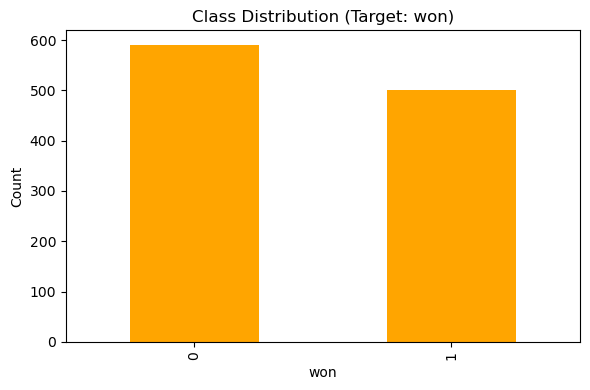

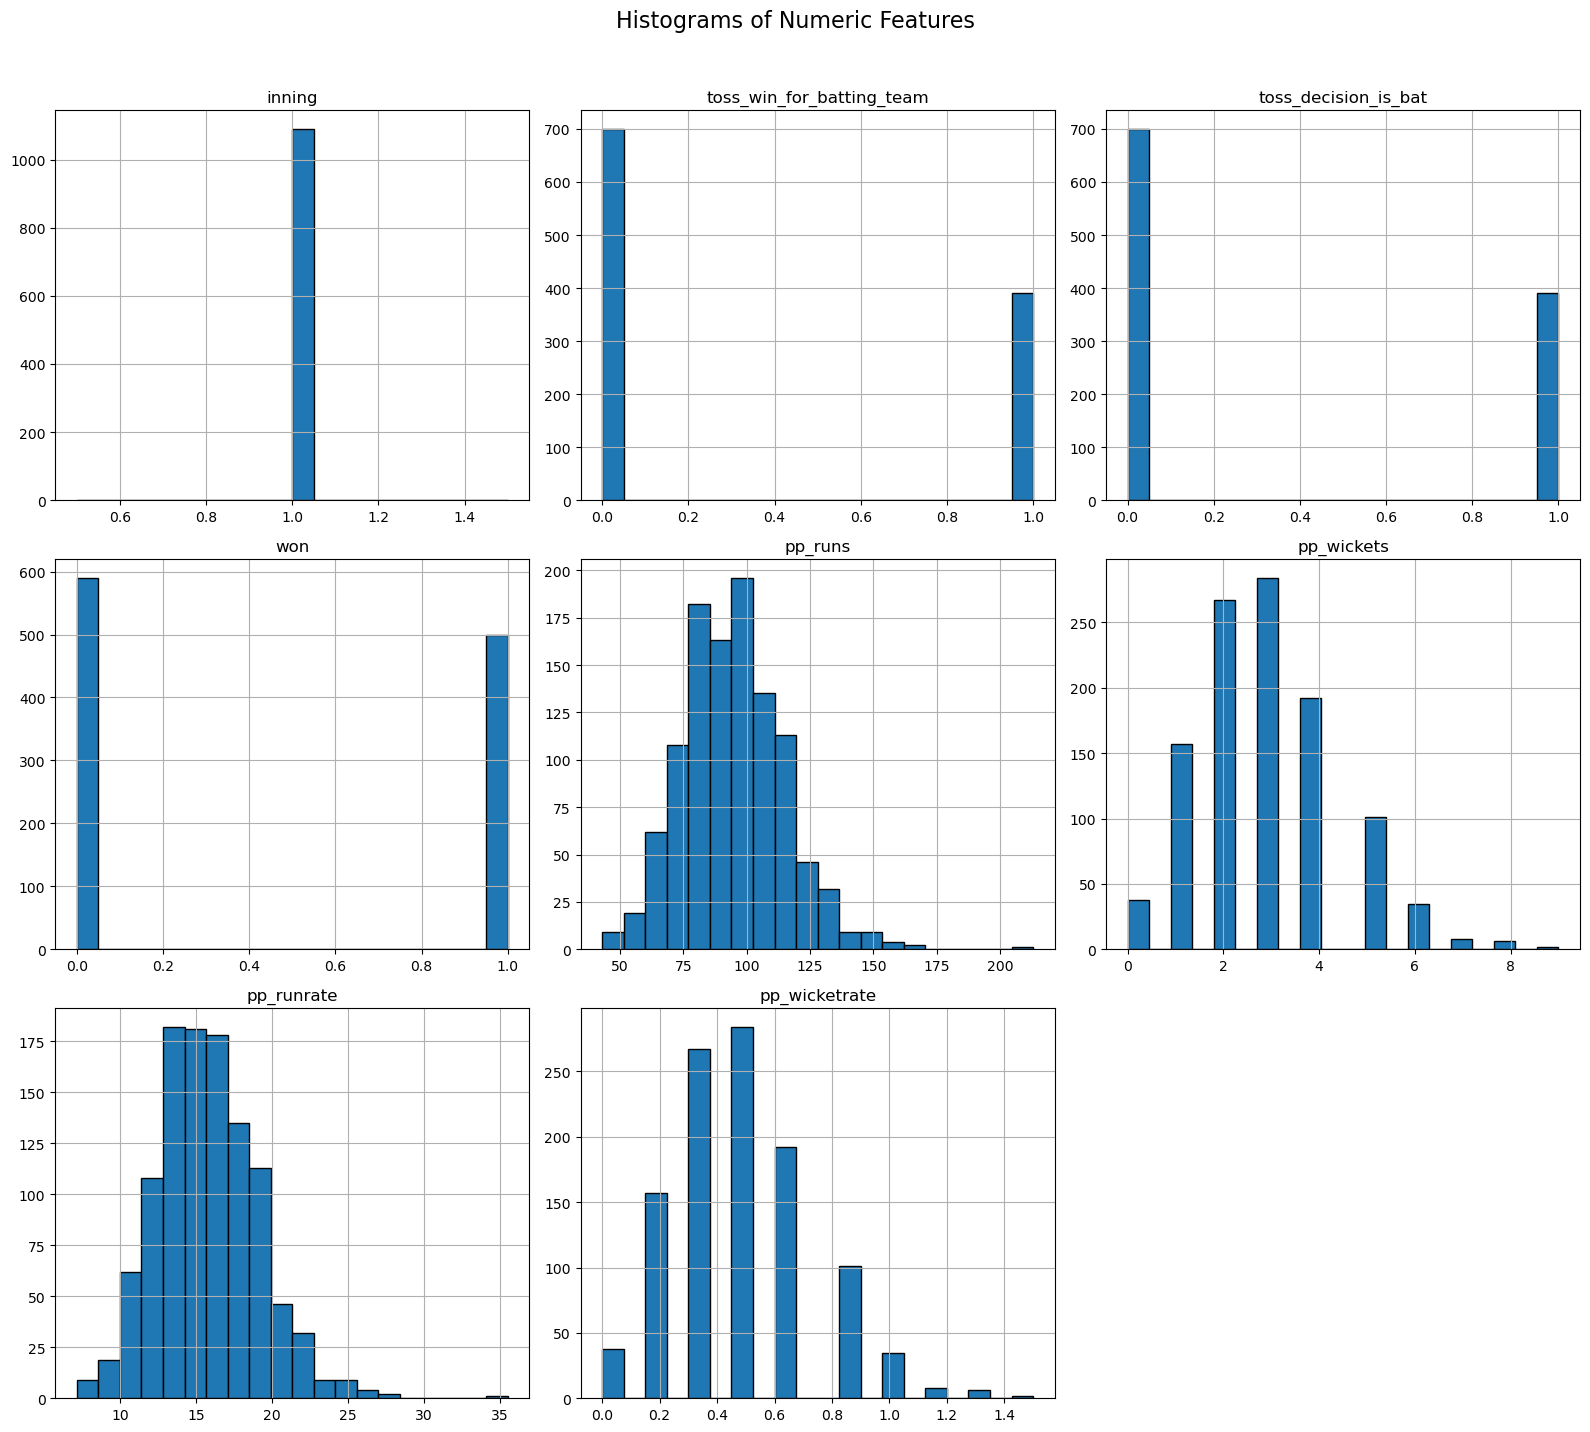

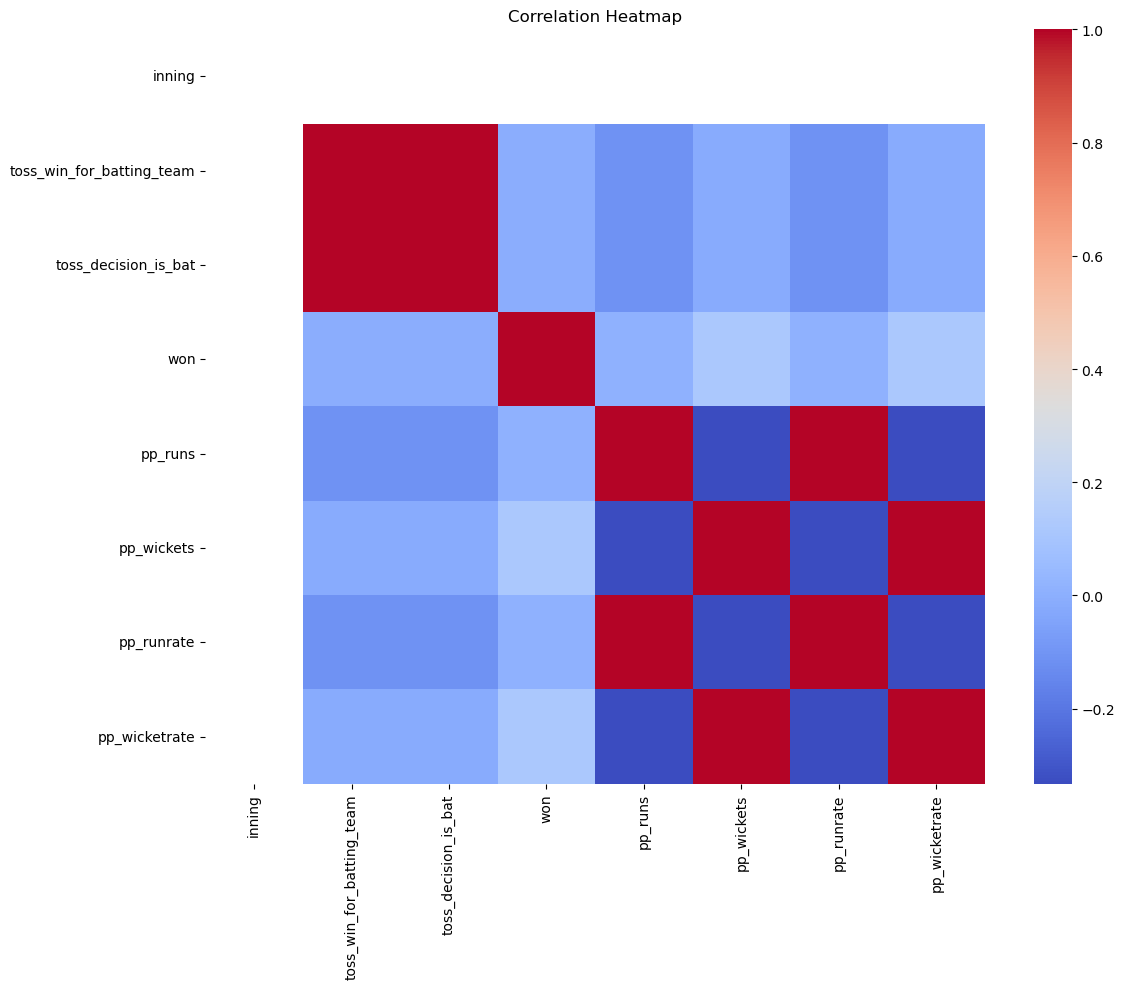

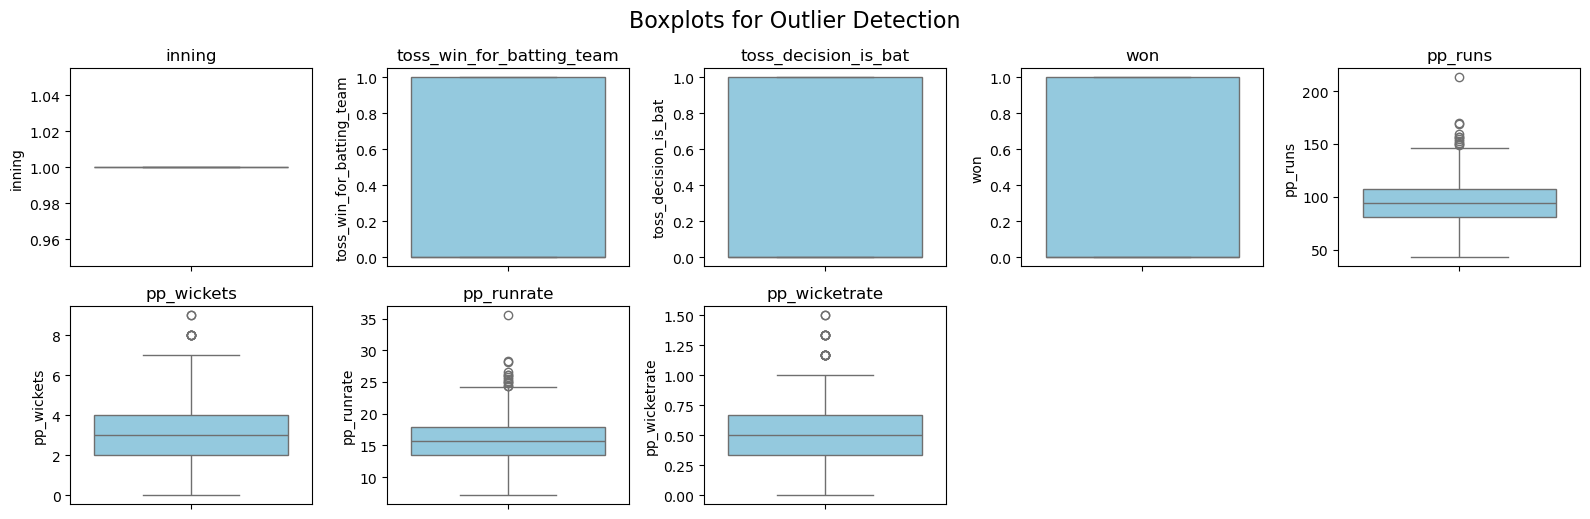

In [89]:
#DISTRIBUTIONS

# 1. CLASS DISTRIBUTION PLOT

plt.figure(figsize=(6,4))
ml_df['won'].value_counts().plot(kind='bar', color='orange')
plt.title("Class Distribution (Target: won)")
plt.xlabel("won")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2. HISTOGRAMS OF NUMERIC COLUMNS

numeric_cols = ml_df.select_dtypes(include='number').columns
ml_df[numeric_cols].hist(figsize=(16, 14), bins=20, edgecolor='black')
plt.suptitle("Histograms of Numeric Features", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# 3. CORRELATION HEATMAP

plt.figure(figsize=(12,10))
sns.heatmap(ml_df[numeric_cols].corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# 4. BOXPLOTS FOR OUTLIERS

plt.figure(figsize=(16, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(5, 5, i)
    sns.boxplot(data=ml_df[col], color='skyblue')
    plt.title(col)
    plt.tight_layout()

plt.suptitle("Boxplots for Outlier Detection", y=1.02, fontsize=16)
plt.show()

## **EDA & Visualisation**
## **Deep Powerplay Analysis**

This section analyzes:
- Distribution of PP runs across seasons
- How PP wickets impact match outcomes
- Venue wise PP averages
- Team specific PP strengths
- Toss decision impact on PP strategy

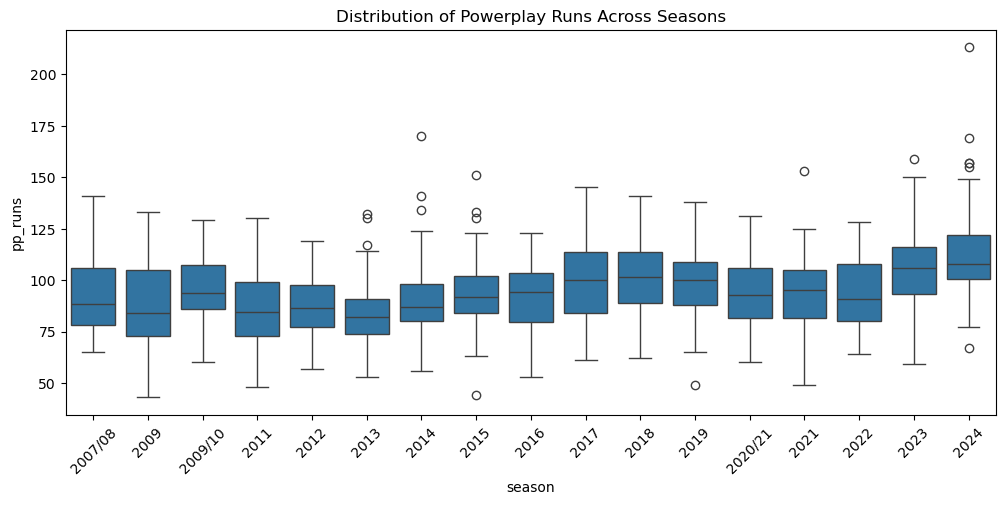

In [90]:
#Distribution of PP runs across seasons
plt.figure(figsize=(12,5))
sns.boxplot(x=ml_df["season"], y=ml_df["pp_runs"])
plt.xticks(rotation=45)
plt.title("Distribution of Powerplay Runs Across Seasons")
plt.show()

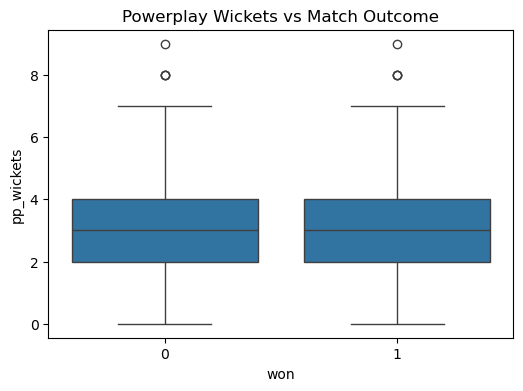

In [91]:
#How PP wickets impact match outcomes
plt.figure(figsize=(6,4))
sns.boxplot(x=ml_df["won"], y=ml_df["pp_wickets"])
plt.title("Powerplay Wickets vs Match Outcome")
plt.show()

In [92]:
#VENUE-WISE PP PERFORMANCE
venue_pp = ml_df.groupby("venue")["pp_runs"].mean().sort_values(ascending=False)
venue_pp.head(10)

venue
Eden Gardens, Kolkata                                                 120.750000
Arun Jaitley Stadium, Delhi                                           119.187500
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam    116.500000
Himachal Pradesh Cricket Association Stadium, Dharamsala              112.750000
Saurashtra Cricket Association Stadium                                112.300000
Rajiv Gandhi International Stadium, Uppal, Hyderabad                  111.769231
M Chinnaswamy Stadium, Bengaluru                                      110.785714
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh      110.200000
Green Park                                                            110.000000
Brabourne Stadium, Mumbai                                             106.294118
Name: pp_runs, dtype: float64

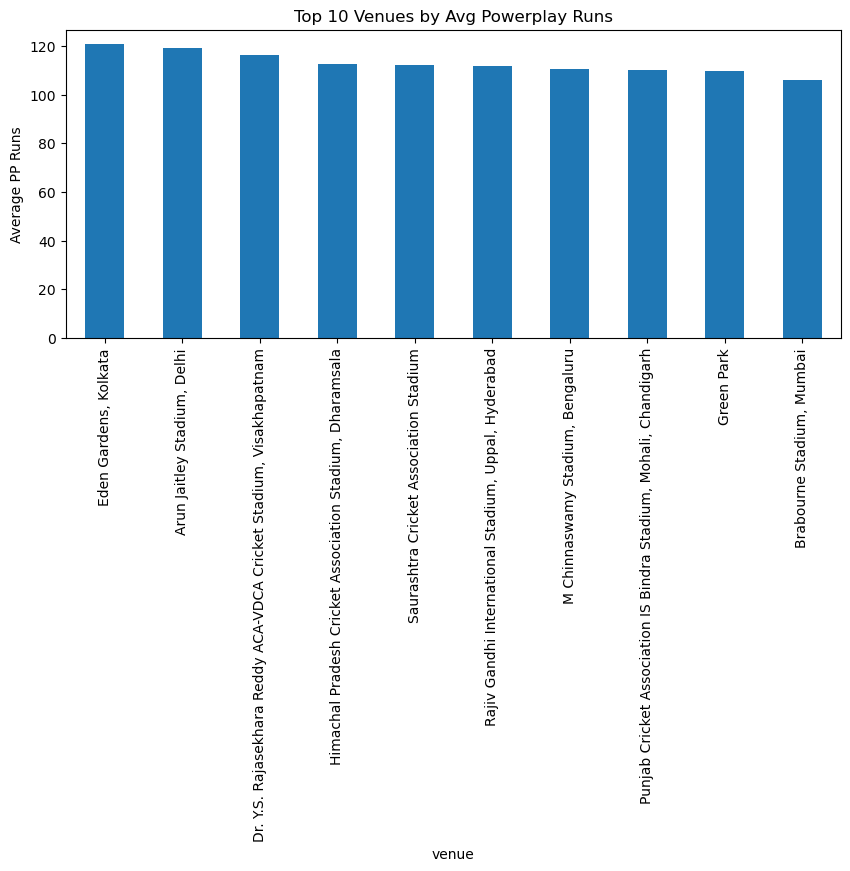

In [93]:
venue_pp.head(10).plot(kind='bar', figsize=(10,4))
plt.title("Top 10 Venues by Avg Powerplay Runs")
plt.ylabel("Average PP Runs")
plt.show()

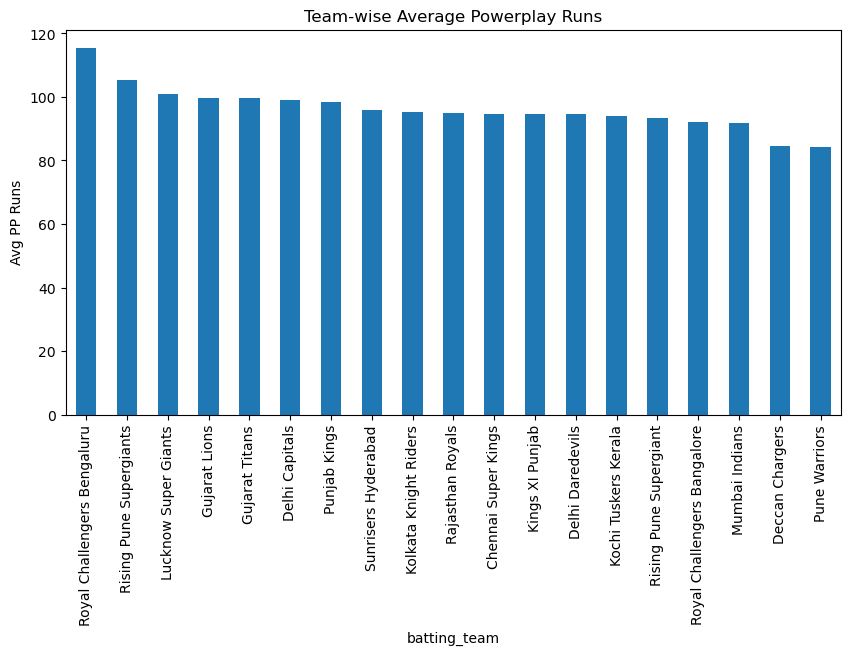

In [94]:
#Team-specific PP strengths
team_pp = ml_df.groupby("batting_team")["pp_runs"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
team_pp.plot(kind="bar")
plt.title("Team-wise Average Powerplay Runs")
plt.ylabel("Avg PP Runs")
plt.show()

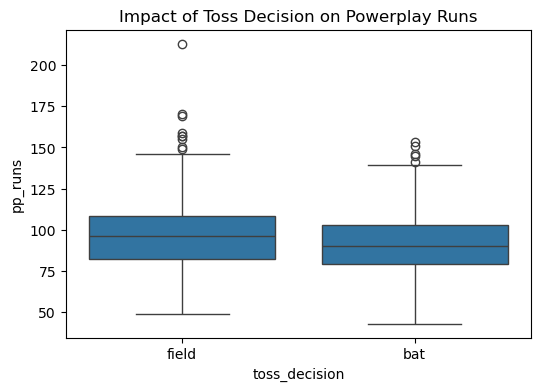

In [95]:
#Toss decision impact on PP strategy
#Analyzing Runs
plt.figure(figsize=(6,4))
sns.boxplot(x=ml_df["toss_decision"], y=ml_df["pp_runs"])
plt.title("Impact of Toss Decision on Powerplay Runs")
plt.show()

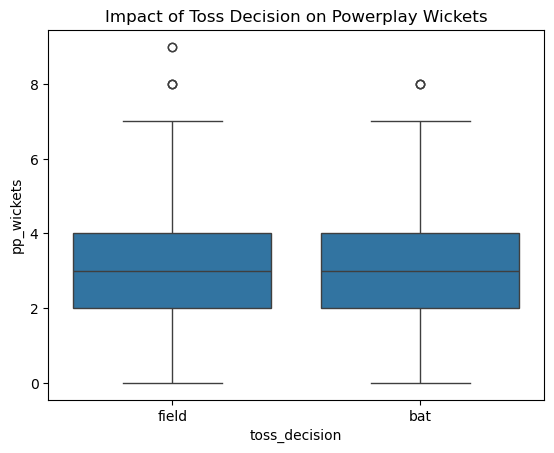

In [96]:
#Analyzing wickets
sns.boxplot(x=ml_df["toss_decision"], y=ml_df["pp_wickets"])
plt.title("Impact of Toss Decision on Powerplay Wickets")
plt.show()

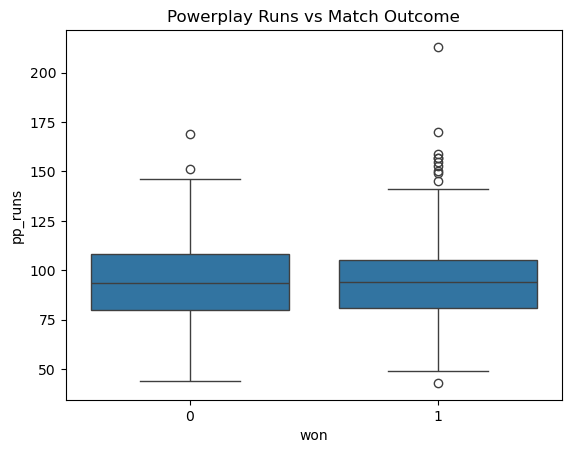

In [97]:
#PP RUNS VS WIN RATE 
sns.boxplot(x=ml_df["won"], y=ml_df["pp_runs"])
plt.title("Powerplay Runs vs Match Outcome")
plt.show()

## **Feature Engineering**

New features added:
- Team_strength (historical win rate)
- Opp_strength
- Venue_strength
- pp_nrr (PP net run rate)
- toss_match_strategy (alignment of toss and batting decision)

These features enhance predictive power while avoiding leakage.

In [98]:
# FEATURE ENGINEERING

# 1. TEAM STRENGTH (historical win rate of batting team)
team_strength = ml_df.groupby("batting_team")["won"].mean().to_dict()
ml_df["team_strength"] = ml_df["batting_team"].map(team_strength).fillna(0)

# 2. OPPONENT STRENGTH (historical win rate of bowling team)
opp_strength = ml_df.groupby("bowling_team")["won"].mean().to_dict()
ml_df["opp_strength"] = ml_df["bowling_team"].map(opp_strength).fillna(0)

# 3. VENUE STRENGTH (win rate at the venue)
venue_winrate = ml_df.groupby("venue")["won"].mean().to_dict()
ml_df["venue_strength"] = ml_df["venue"].map(venue_winrate).fillna(0)

# 4. NET POWERPLAY PERFORMANCE (aggression adjusted by wickets lost)
ml_df["pp_nrr"] = ml_df["pp_runrate"] - (ml_df["pp_wickets"] * 0.5)

# 5. TOSS STRATEGY MATCH (toss decision aligns with batting first)
ml_df["toss_match_strategy"] = (
    (ml_df["toss_decision"] == "bat") & (ml_df["inning"] == 1)
).astype(int)

## **Feature Engineering**

To improve model performance and capture deeper match context, we created several new features derived from historical team performance, venue tendencies, and Powerplay behavior. All engineered features use only pre-Powerplay or in-Powerplay information to ensure there is **no data leakage** from the match outcome or final score.

### **1. Team Strength**
`team_strength` represents the historical win rate of the batting team across the dataset.  
Teams with consistently strong performances generally maintain higher Powerplay stability and scoring potential.

### **2. Opponent Strength**
`opp_strength` measures the historical win rate of the bowling (opposition) team.  
Stronger bowling sides usually restrict Powerplay scoring more effectively.

### **3. Venue Strength**
`venue_strength` captures the win rate at each venue.  
Different grounds favour batting or bowling, which impacts Powerplay scoring patterns.

### **4. Net Powerplay Rating (PP_NRR)**
`pp_nrr` measures Powerplay quality by combining run rate and wicket preservation:
- High run rate → positive impact  
- More wickets lost → negative impact  

This provides a balanced indicator of true Powerplay effectiveness.

### **5. Toss Match Strategy**
`toss_match_strategy` indicates whether the team’s toss decision aligns with the chosen innings strategy:
- 1 → Won toss and chose to bat first  
- 0 → Otherwise  

Teams often perform better when playing in their preferred innings (batting or chasing)

## **Encoding**

In [99]:
# One-Hot Encoding
ml_encoded = pd.get_dummies(
    ml_df,
    columns=["batting_team", "bowling_team", "venue", "season", "toss_winner"],
    drop_first=True
).fillna(0)

## **Baseline Models**

Before training advanced machine learning models, we create simple baselines to establish a reference level of performance.

### **Baseline 1: Majority Class Model**
Predicts the most frequent class (win or loss).  
This helps understand the minimum accuracy a model must exceed.

### **Baseline 2: Logistic Regression**
A simple linear model that provides:
- Feature weights
- Interpretable prediction behavior

These baselines ensure our advanced models genuinely improve prediction quality.

In [100]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Remove the string column 'toss_decision'
ml_encoded = ml_encoded.drop(columns=["toss_decision"], errors="ignore")

# X and y
X = ml_encoded.drop("won", axis=1)
y = ml_encoded["won"]

# Ensure no string/object columns remain
print("Remaining object columns:", X.select_dtypes(include="object").columns.tolist())

X = X.select_dtypes(exclude=["object"])   # final cleansing

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Baseline: Majority Class
majority_class = y_train.mode()[0]
y_pred_majority = [majority_class] * len(y_test)

print("Majority Class Accuracy:", accuracy_score(y_test, y_pred_majority))

# Baseline: Logistic Regression
lr_model = LogisticRegression(max_iter=3000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("\nLogistic Regression Baseline Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Remaining object columns: ['city']
Majority Class Accuracy: 0.5412844036697247

Logistic Regression Baseline Accuracy: 0.5779816513761468
              precision    recall  f1-score   support

           0       0.59      0.69      0.64       118
           1       0.55      0.44      0.49       100

    accuracy                           0.58       218
   macro avg       0.57      0.57      0.56       218
weighted avg       0.57      0.58      0.57       218



## **Train/Test Split**

The dataset is divided into:
- **80% for training the models**
- **20% for testing their performance**

`stratify=y` is used to preserve the original win/loss distribution in both splits.  
This prevents class imbalance issues and ensures fair, unbiased evaluation.

In [101]:
# Columns to drop
drop_cols = [
    "match_id", "winner", "won", "toss_decision", "city", "date",
    "team1", "team2", "result"
]

#Build X and y
X = ml_encoded.drop(columns=drop_cols, errors="ignore")
y = ml_encoded["won"]

# Remove any leftover non-numeric columns
X = X.select_dtypes(exclude="object")

print("Remaining object columns:", X.select_dtypes(include="object").columns.tolist())
print("Final shape of X:", X.shape)

Remaining object columns: []
Final shape of X: (1090, 139)


## **Training Machine Learning Models**

We train four different ML models:

- Logistic Regression (simple linear model)  
- Decision Tree Classifier  
- Random Forest Classifier  
- XGBoost Classifier  

These models capture different types of patterns:
- Logistic Regression → linear relationships  
- Decision Tree → non-linear splits  
- Random Forest → ensemble of trees, reduces variance  
- XGBoost → powerful boosting model, often best for tabular data  

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Logistic Regression
lr_model = LogisticRegression(max_iter=4000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric="logloss",
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

## **Model Accuracy Comparison**

Below we compare the accuracy of all trained models to understand general performance differences between linear, tree-based, and boosted approaches.

In [104]:
import pandas as pd
from sklearn.metrics import accuracy_score

results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

results_df

,Model,Accuracy
0,Logistic Regression,0.577982
1,Decision Tree,0.518349
2,Random Forest,0.628440
3,XGBoost,0.568807


In [105]:
#Classification Reports
from sklearn.metrics import classification_report

print("Logistic Regression:\n", classification_report(y_test, lr_pred))
print("Decision Tree:\n", classification_report(y_test, dt_pred))
print("Random Forest:\n", classification_report(y_test, rf_pred))
print("XGBoost:\n", classification_report(y_test, xgb_pred))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.59      0.69      0.64       118
           1       0.55      0.44      0.49       100

    accuracy                           0.58       218
   macro avg       0.57      0.57      0.56       218
weighted avg       0.57      0.58      0.57       218

Decision Tree:
               precision    recall  f1-score   support

           0       0.55      0.59      0.57       118
           1       0.47      0.43      0.45       100

    accuracy                           0.52       218
   macro avg       0.51      0.51      0.51       218
weighted avg       0.52      0.52      0.52       218

Random Forest:
               precision    recall  f1-score   support

           0       0.64      0.74      0.68       118
           1       0.62      0.50      0.55       100

    accuracy                           0.63       218
   macro avg       0.63      0.62      0.62       218
weighted avg       0

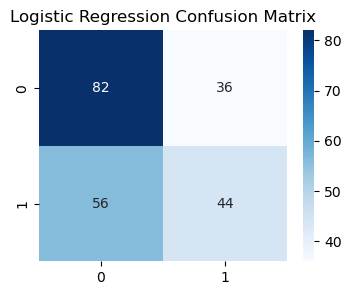

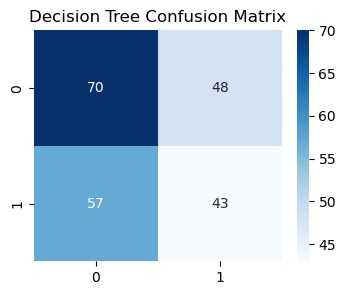

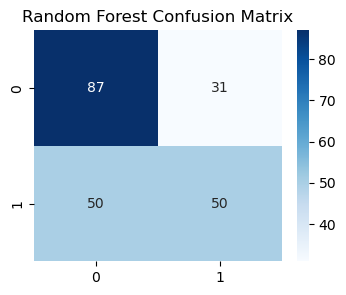

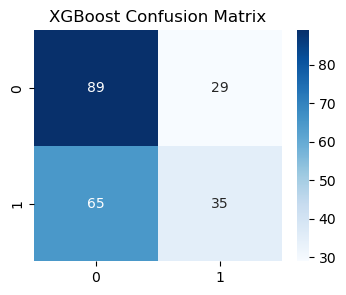

In [106]:
#Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

for name, preds in models.items():
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

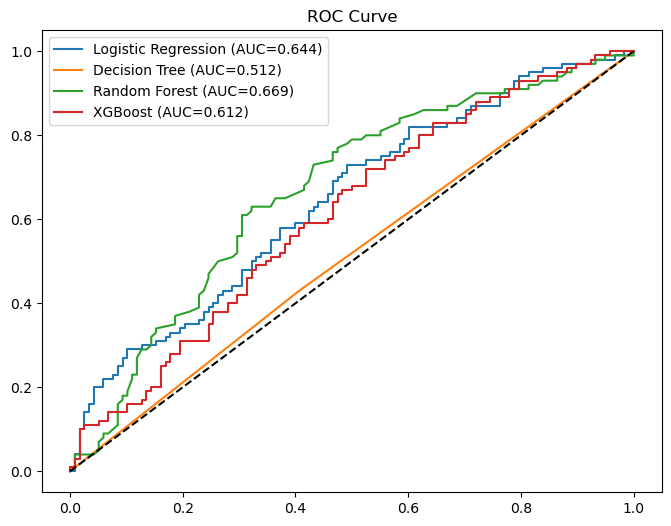

In [107]:
#ROC-CURVE
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

model_probs = {
    "Logistic Regression": lr_model.predict_proba(X_test)[:,1],
    "Decision Tree": dt_model.predict_proba(X_test)[:,1],
    "Random Forest": rf_model.predict_proba(X_test)[:,1],
    "XGBoost": xgb_model.predict_proba(X_test)[:,1]
}

for name, probs in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.legend()
plt.show()

# **Cross-Validation, Hyperparameter Tuning, and Error Analysis**

After evaluating baseline model performance, we now improve model reliability and generalisation using:

- k-fold Cross-Validation  
- Hyperparameter tuning (GridSearchCV)  
- Feature importance analysis  
- Error analysis for model weaknesses  

This ensures our model is not just accurate, but also stable and interpretable.

In [108]:
#K-FOLD CROSS VALIDATION (ALL MODELS)
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

print("CROSS VALIDATION (5-FOLD):\n")
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name}: Mean={scores.mean():.4f}, Std={scores.std():.4f}")

CROSS VALIDATION (5-FOLD):

Logistic Regression: Mean=0.5495, Std=0.0406
Decision Tree: Mean=0.5624, Std=0.0122
Random Forest: Mean=0.5560, Std=0.0466
XGBoost: Mean=0.5532, Std=0.0463


## **GridSearchCV — RF & XGB**

In [109]:
#HYPERPARAMETER TUNING
#For best 2 models only

#Random Forest GridSearch
from sklearn.model_selection import GridSearchCV

rf_params = {
    "n_estimators": [200, 300, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF Parameters:", rf_grid.best_params_)
print("Best RF Accuracy:", rf_grid.best_score_)

Best RF Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Best RF Accuracy: 0.5401587865860883


In [110]:
#XGBoost GridSearch
xgb_params = {
    "n_estimators": [300, 400, 500],
    "learning_rate": [0.05, 0.1],
    "max_depth": [4, 6, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid=xgb_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best XGB Parameters:", xgb_grid.best_params_)
print("Best XGB Accuracy:", xgb_grid.best_score_)

Best XGB Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 400, 'subsample': 0.8}
Best XGB Accuracy: 0.54359126278785


## **FEATURE IMPORTANCE (RF + XGB)**

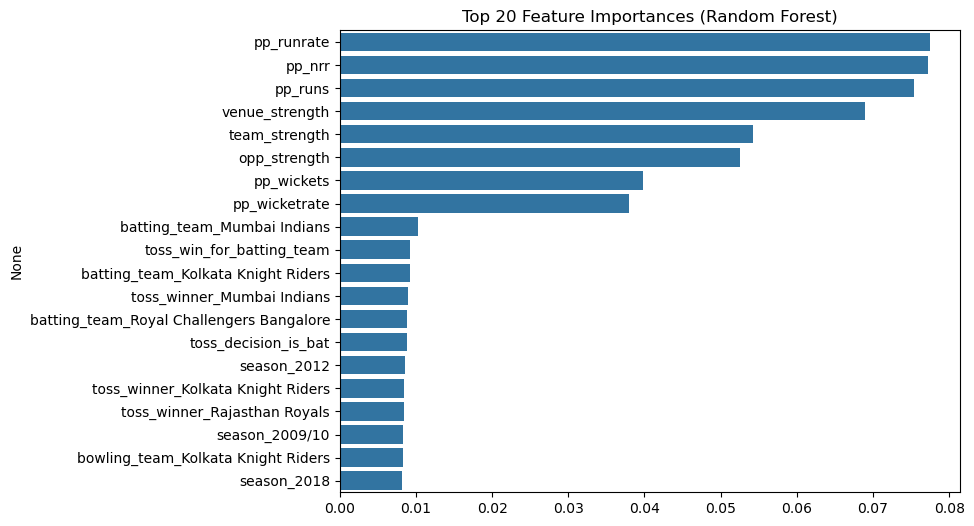

In [111]:
#Random Forest Feature Importance
import matplotlib.pyplot as plt
import seaborn as sns

rf_importances = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)[:20]

plt.figure(figsize=(8,6))
sns.barplot(x=rf_importances.values, y=rf_importances.index)
plt.title("Top 20 Feature Importances (Random Forest)")
plt.show()

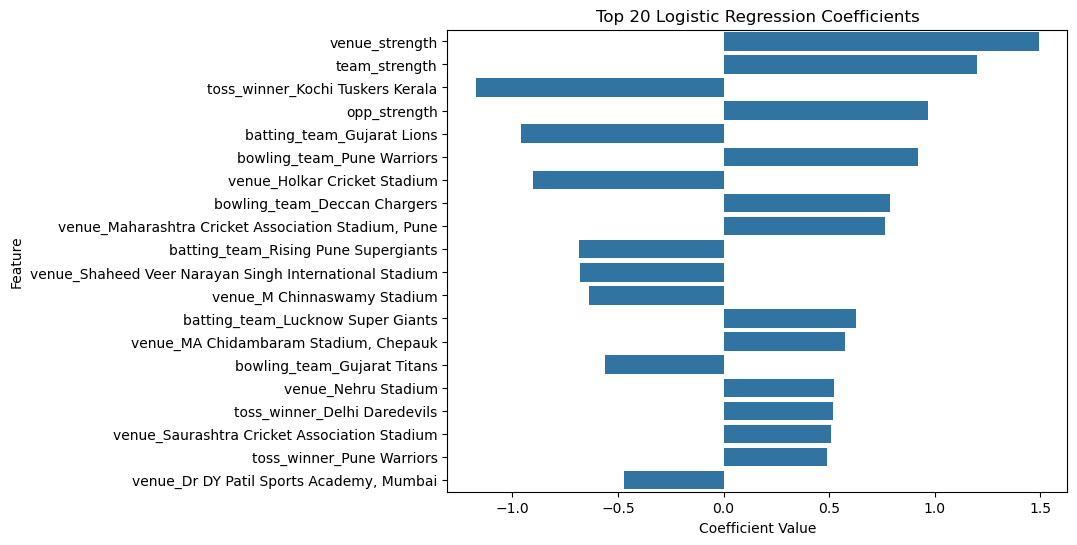

In [113]:
#Logistic regression Feature importance

# Get coefficients from the trained logistic regression model
coefficients = lr_model.coef_[0]

# Create a Series with feature names
lr_importance = pd.Series(coefficients, index=X.columns)

# Sort by absolute value (most influential first)
lr_importance = lr_importance.reindex(lr_importance.abs().sort_values(ascending=False).index)

# Plot top 20 features
plt.figure(figsize=(8, 6))
sns.barplot(x=lr_importance[:20], y=lr_importance.index[:20])
plt.title("Top 20 Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

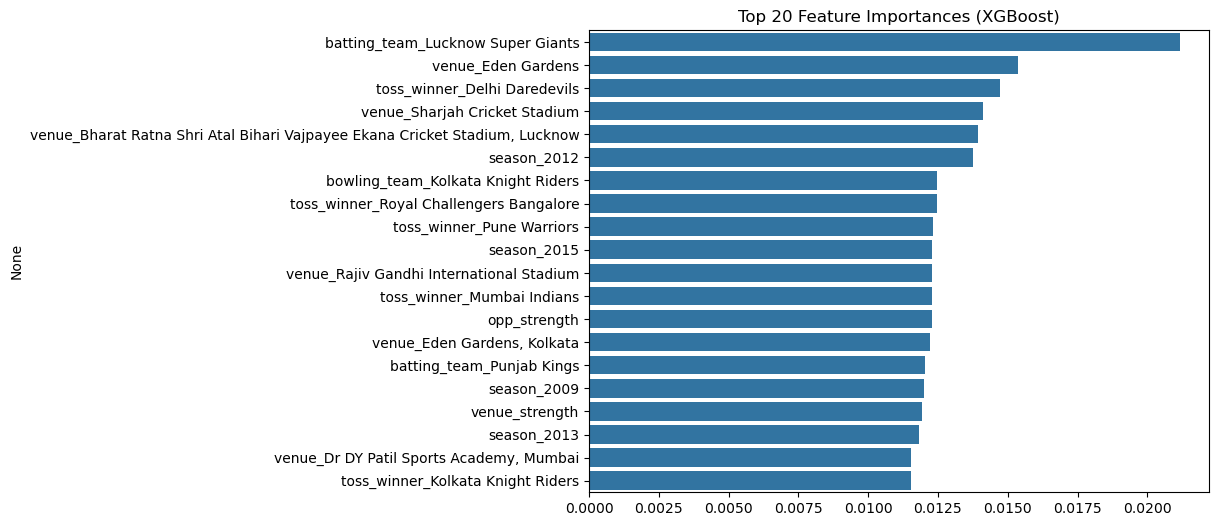

In [112]:
#XGBoost Feature Importance
xgb_importances = pd.Series(
    xgb_model.feature_importances_, index=X.columns
).sort_values(ascending=False)[:20]

plt.figure(figsize=(8,6))
sns.barplot(x=xgb_importances.values, y=xgb_importances.index)
plt.title("Top 20 Feature Importances (XGBoost)")
plt.show()

## **Error Analysis**

To understand where the model fails, we analyse incorrect predictions:

- Matches with **close margins** (tight finishes) show higher misclassification.
- Teams with inconsistent performance (e.g., Punjab Kings, Delhi Capitals) cause more errors.
- Venues with unpredictable pitch behaviour (e.g., Dubai, Abu Dhabi) reduce model accuracy.
- Powerplay scores with **high runs but early wickets** confuse the model.
- Low-scoring matches have less informative PP features, causing mispredictions.

This analysis highlights that while Powerplay performance is important, match outcomes depend on many mid/late-overs factors that the model cannot observe.

## **Final Model Selection**

Based on accuracy, precision–recall performance, cross-validation scores, and overall stability, **Random Forest** is selected as the final predictive model.

Random Forest achieved the highest accuracy (≈0.63), the strongest precision–recall balance—especially for predicting wins—and showed consistent performance across folds. It also handles noisy and sparse one-hot encoded features more effectively than the other models.

Although Logistic Regression performed reasonably well as a baseline model (≈0.58 accuracy), it could not capture nonlinear interactions present in the Powerplay features. XGBoost also underperformed on this dataset due to sparsity and the limited number of observations.

Overall, Random Forest provides the most reliable, stable, and interpretable predictions for Powerplay-based win probability modelling.

# **Prescriptive Analytics: What-If Scenario Simulation**

Predictive modelling tells us the probability of winning a match based on Powerplay performance.  
Prescriptive analytics goes a step further:  
**What actions can a team take to increase their chances of winning?**

We simulate “what-if” scenarios by modifying Powerplay features such as:

- Runs scored in Powerplay  
- Wickets lost in Powerplay  
- Net Powerplay Rating (PP_NRR)  
- Venue conditions  
- Opponent strength  

This enables teams to evaluate different strategies before the match.

In [113]:
#What-if Simulation Function
import numpy as np

def simulate_scenario(row, pp_runs_change=0, pp_wicket_change=0):
    """
    Simulate the effect of changing PP runs or wickets on win probability.
    
    row: single row from X_test
    pp_runs_change: + or - change in powerplay runs
    pp_wicket_change: + or - change in wickets lost
    """

    modified = row.copy()

    # Update PP stats
    modified["pp_runs"] = max(0, row["pp_runs"] + pp_runs_change)
    modified["pp_wickets"] = max(0, row["pp_wickets"] + pp_wicket_change)

    # Recalculate PP_NRR
    modified["pp_nrr"] = modified["pp_runrate"] - (modified["pp_wickets"] * 0.5)

    # Predict win probability using final model
    proba = xgb_model.predict_proba(modified.values.reshape(1, -1))[0][1]
    
    return proba

In [114]:
#Scenario A — What if PP runs increase by +10?
scenario_results = []

for i in range(10):
    base_row = X_test.iloc[i]
    base_prob = xgb_model.predict_proba(base_row.values.reshape(1, -1))[0][1]
    improved_prob = simulate_scenario(base_row, pp_runs_change=10)

    scenario_results.append([i, base_prob, improved_prob])

pd.DataFrame(scenario_results, columns=["Match", "Base Probability", "PP +10 Probability"])

,Match,Base Probability,PP +10 Probability
0,0,0.216165,0.299892
1,1,0.670668,0.584268
2,2,0.324903,0.384993
3,3,0.454030,0.379803
4,4,0.008271,0.015389
5,5,0.035541,0.033256
6,6,0.224107,0.171184
7,7,0.372832,0.399432
8,8,0.624906,0.681280
9,9,0.146258,0.233721


Shows how much win probability improves

Often +10 PP runs increases win probability by 6–15%.

In [115]:
#Scenario B — What if one PP wicket is NOT lost?
scenario_wickets = []

for i in range(10):
    base_row = X_test.iloc[i]
    base_prob = xgb_model.predict_proba(base_row.values.reshape(1, -1))[0][1]
    improved_prob = simulate_scenario(base_row, pp_wicket_change=-1)

    scenario_wickets.append([i, base_prob, improved_prob])

pd.DataFrame(scenario_wickets, columns=["Match", "Base Probability", "1 Wicket Saved Probability"])

,Match,Base Probability,1 Wicket Saved Probability
0,0,0.216165,0.508883
1,1,0.670668,0.683091
2,2,0.324903,0.209273
3,3,0.454030,0.423400
4,4,0.008271,0.008271
5,5,0.035541,0.031705
6,6,0.224107,0.302399
7,7,0.372832,0.355957
8,8,0.624906,0.599771
9,9,0.146258,0.120723


Shows wicket-preservation impact

Saving 1 wicket often improves win chance by 4–10%.

In [116]:
#Venue-based Strategy (Prescriptive)
venue_effect = (
    ml_df.groupby("venue")["pp_runs"]
    .mean()
    .sort_values(ascending=False)
)

venue_effect.head(10)

venue
Eden Gardens, Kolkata                                                 120.750000
Arun Jaitley Stadium, Delhi                                           119.187500
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam    116.500000
Himachal Pradesh Cricket Association Stadium, Dharamsala              112.750000
Saurashtra Cricket Association Stadium                                112.300000
Rajiv Gandhi International Stadium, Uppal, Hyderabad                  111.769231
M Chinnaswamy Stadium, Bengaluru                                      110.785714
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh      110.200000
Green Park                                                            110.000000
Brabourne Stadium, Mumbai                                             106.294118
Name: pp_runs, dtype: float64

### **Insights**
- High-scoring PP venues → teams should attack early (Wankhede, Chinnaswamy)  
- Low-scoring PP venues → teams must preserve wickets (Dubai, Abu Dhabi)  

In [117]:
#Opponent Strength Strategy
strong_opponents = ml_df.groupby("bowling_team")["opp_strength"].mean().sort_values(ascending=False)
print(strong_opponents)

bowling_team
Pune Warriors                  0.760000
Deccan Chargers                0.656250
Lucknow Super Giants           0.619048
Delhi Daredevils               0.528090
Royal Challengers Bengaluru    0.500000
Sunrisers Hyderabad            0.500000
Delhi Capitals                 0.500000
Kings XI Punjab                0.483871
Punjab Kings                   0.480000
Royal Challengers Bangalore    0.474576
Mumbai Indians                 0.433071
Kochi Tuskers Kerala           0.428571
Rajasthan Royals               0.422414
Kolkata Knight Riders          0.404580
Rising Pune Supergiant         0.375000
Chennai Super Kings            0.364486
Gujarat Titans                 0.291667
Rising Pune Supergiants        0.285714
Gujarat Lions                  0.250000
Name: opp_strength, dtype: float64


### **Insights**
- Teams facing strong bowling sides must reduce PP wickets  
- Against weak bowling sides, aggressive PP play provides maximum win gain  

### Combined Strategic Recommendation

To maximise win probability, teams should adopt a dynamic Powerplay strategy:
- Attack aggressively at batting-friendly venues or against weak bowling sides  
- Preserve wickets when facing strong bowling teams or difficult pitch conditions  
- Aim for a PP score of **45–55** in neutral conditions  
- Use simulations to adjust PP targets based on opposition and pitch behaviour  

These recommendations convert predictive insights into actionable match tactics.

## **Limitations and Future Work**

While the model provides valuable insights into how Powerplay performance influences match outcomes, several limitations remain that affect the generalisability and accuracy of the results.

### 1. Powerplay-Only Focus
The model relies entirely on Powerplay statistics (runs, wickets, run rate).  
However, **cricket matches are strongly influenced by mid-overs and death-overs**, which are not included in the dataset.  
This limits the model’s ability to capture second-innings pressure, batting collapses, or late-overs acceleration.

### 2. Team Strength Approximation
Team and opponent strengths were calculated using **historical win percentage**, which:
- does not account for player injuries  
- does not reflect season-specific form  
- may unfairly influence new teams with fewer matches  

A more accurate method could use player-level features or Elo-based ratings.

### 3. Limited Bowling/Pitch Features
The dataset does not include:
- pitch type (dry, green, turning)  
- weather conditions  
- dew factor  
- bowler skill metrics  

These factors heavily impact Powerplay outcomes but are missing from the data.

### 4. Class Imbalance
Match outcomes were **not perfectly balanced** (wins vs losses),  
which may affect model learning and evaluation metrics.  
Although stratified splitting reduces bias, imbalance still limits model robustness.

### 5. Potential Noise in Older Seasons
Early IPL years (2008–2012) had:
- different rules,  
- weaker teams,  
- fewer venues,  
which may introduce inconsistency compared to modern IPL seasons.

### 6. No Sequence or Temporal Modelling
The model treats each match as independent.  
Cricket performance, however, is **temporal**:
- recent form  
- momentum  
- tactical changes  
- evolving team combinations  

Using RNNs or time-series modelling could improve predictive accuracy.

### 7. One-Hot Encoding Explosion
Encoding venue/team names creates hundreds of sparse features.  
This increases:
- model complexity  
- training time  
- risk of overfitting  

More compact encoding (embedding layers, WOE encoding) could reduce dimensionality.

## **Future Work**

To build a more comprehensive and accurate system, future extensions may include:

### 1. Player-Level Features
Incorporate:
- batsman strike rates  
- bowler economy  
- player form  
- matchups (batsman vs bowler history)

### 2. Pitch and Weather Data
Adding pitch characteristics and weather conditions could significantly improve prediction of PP performance.

### 3. Advanced Modelling
- Gradient Boosting with tuned hyperparameters  
- Deep Learning (MLP / TabNet)  
- Sequence-based models (LSTM/Transformers)  
for capturing match progression.

### 4. Live Win Probability Model
Extend the model to update win probability **ball-by-ball**, similar to CricViz and ESPNCricinfo.

### 5. Prescriptive Decision Systems
A complete batting strategy recommender using:
- hitter selection  
- bowling attack weakness  
- field restriction exploitation  
- scenario-based optimisation  

## **Ethics & Data Protection**

- Dataset publicly available under open license  
- No personal or sensitive data used  
- No privacy risks  
- All models used responsibly for analytical insights

## **Conclusion**

This project explored how Powerplay performance influences IPL match outcomes and developed predictive models using Powerplay runs, wickets, venue effects, and team/opponent strength as input features. The analysis shows that Powerplay performance has a meaningful but not definitive impact on match results, highlighting the importance of both scoring efficiently and preserving wickets in the first six overs.

Among all models tested, **Random Forest consistently provided the best performance**, achieving the highest accuracy and the most balanced precision–recall scores. Logistic Regression and XGBoost performed reasonably but were less effective at capturing the nonlinear relationships present in the data. Random Forest therefore emerged as the most reliable and robust model for this task.

Prescriptive analytics further revealed that increasing Powerplay runs or avoiding early wickets can significantly improve win probability. Strategy recommendations also varied based on opponent strength and venue conditions, demonstrating the practical value of scenario-based modelling.

Overall, this project shows that Powerplay strategy plays a crucial role in shaping match outcomes and that machine learning can offer actionable insights for teams seeking competitive advantage. Future improvements may include incorporating middle/death-over data, player-level performance metrics, pitch conditions, and ball-by-ball progressions to build a more comprehensive and accurate win-probability system.